# Chapter 9: Flow Assurance — Hydrates, Wax, and Corrosion

This notebook demonstrates flow assurance calculations using NeqSim, focusing
on **hydrate formation prediction**, **MEG inhibition**, and **water dew point**
analysis — critical topics for safe and reliable production operations.

**Topics covered:**
- Hydrate equilibrium curve generation
- MEG (mono-ethylene glycol) inhibition effect on hydrate temperature
- Water dew point temperature vs pressure
- Pipeline operating envelope with hydrate boundaries

In [1]:
# Execute against the selected, compiled NeqSim source checkout.
import os
import sys
from pathlib import Path
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import jpype

if not os.environ.get("NEQSIM_PROJECT_ROOT"):
    raise RuntimeError("Set NEQSIM_PROJECT_ROOT to the NeqSim source checkout before running.")
PROJECT_ROOT = Path(os.environ["NEQSIM_PROJECT_ROOT"]).resolve()
if not (PROJECT_ROOT / "devtools" / "neqsim_dev_setup.py").exists():
    raise RuntimeError("NEQSIM_PROJECT_ROOT must contain devtools/neqsim_dev_setup.py.")
sys.path.insert(0, str(PROJECT_ROOT / "devtools"))
from neqsim_dev_setup import neqsim_init, neqsim_classes
ns = neqsim_classes(neqsim_init(project_root=PROJECT_ROOT, recompile=False, verbose=False))
jneqsim = jpype.JPackage("neqsim")
NEQSIM_MODE = "devtools"
NOTEBOOK_PATH = Path(globals().get("__vsc_ipynb_file__", Path.cwd() / "ch08_flow_assurance_figures.ipynb")).resolve()
BOOK_ROOT = NOTEBOOK_PATH.parents[3]
FIGURES_DIR = NOTEBOOK_PATH.parent.parent / "figures"
FIGURES_DIR.mkdir(exist_ok=True)
sys.path.insert(0, str(BOOK_ROOT / "devtools"))
from book_figure_tools import configure_figures, export_figure_summary
configure_figures()
print(f"NeqSim source: {PROJECT_ROOT}; Python: {sys.executable}")

# Named NeqSim class bindings used throughout the chapter.
SystemSrkEos = jneqsim.thermo.system.SystemSrkEos
SystemPrEos = jneqsim.thermo.system.SystemPrEos
SystemSrkCPAstatoil = jneqsim.thermo.system.SystemSrkCPAstatoil
ThermodynamicOperations = jneqsim.thermodynamicoperations.ThermodynamicOperations
Stream = jneqsim.process.equipment.stream.Stream
Separator = jneqsim.process.equipment.separator.Separator
ThreePhaseSeparator = jneqsim.process.equipment.separator.ThreePhaseSeparator
Compressor = jneqsim.process.equipment.compressor.Compressor
Cooler = jneqsim.process.equipment.heatexchanger.Cooler
Heater = jneqsim.process.equipment.heatexchanger.Heater
HeatExchanger = jneqsim.process.equipment.heatexchanger.HeatExchanger
Mixer = jneqsim.process.equipment.mixer.Mixer
Splitter = jneqsim.process.equipment.splitter.Splitter
ThrottlingValve = jneqsim.process.equipment.valve.ThrottlingValve
Pump = jneqsim.process.equipment.pump.Pump
Expander = jneqsim.process.equipment.expander.Expander
Recycle = jneqsim.process.equipment.util.Recycle
ProcessSystem = jneqsim.process.processmodel.ProcessSystem

# Physical verification uses the same model state, source and interpreter.
sys.path.insert(0, str(BOOK_ROOT / "verification" / "scientific_revision"))
from notebook_physics_checks import PhysicsChecks
_physics = PhysicsChecks(NOTEBOOK_PATH)


All NeqSim classes imported OK
NeqSim source: C:\Users\solbraa\OneDrive - NTNU\Documents\ChatGPT\NeqSim; Python: C:\Users\solbraa\.cache\codex-runtimes\codex-primary-runtime\dependencies\python\python.exe


In [2]:
import matplotlib.pyplot as plt
import numpy as np

# jneqsim is bound to the source JVM in the setup cell.

SystemSrkCPAstatoil = jneqsim.thermo.system.SystemSrkCPAstatoil
ThermodynamicOperations = jneqsim.thermodynamicoperations.ThermodynamicOperations


## 9.1 Hydrate Equilibrium Curve

Gas hydrates are ice-like crystalline structures that form when water and
light gas molecules (CH₄, C₂H₆, CO₂, H₂S) are present at high pressure
and low temperature. We calculate the hydrate equilibrium temperature at
various pressures to define the hydrate stability boundary.

In [3]:
def create_hydrate_fluid(T_C=10.0, P_bara=100.0):
    """Create a natural gas + water fluid for hydrate calculations."""
    fluid = SystemSrkCPAstatoil(273.15 + T_C, P_bara)
    fluid.addComponent("methane", 0.80)
    fluid.addComponent("ethane", 0.06)
    fluid.addComponent("propane", 0.03)
    fluid.addComponent("CO2", 0.02)
    fluid.addComponent("water", 0.09)
    fluid.setMixingRule(10)  # CPA mixing rule
    fluid.setMultiPhaseCheck(True)
    fluid.setHydrateCheck(True)
    return fluid

# Calculate hydrate equilibrium curve
pressures_bara = np.array([20, 30, 40, 50, 60, 80, 100, 120, 150, 180, 200])
hydrate_temps_C = []

for P in pressures_bara:
    fluid = create_hydrate_fluid(4.0, float(P))
    ops = ThermodynamicOperations(fluid)
    try:
        ops.hydrateFormationTemperature()
        hydrate_T = float(fluid.getTemperature("C"))
        hydrate_temps_C.append(hydrate_T)
    except Exception:
        raise RuntimeError(f'Hydrate equilibrium failed at {P} bara')

print("Hydrate equilibrium curve calculated.")
for P, T in zip(pressures_bara, hydrate_temps_C):
    print(f"  P = {P:6.0f} bara  ->  T_hydrate = {T:6.1f} °C")
assert np.all(np.isfinite(hydrate_temps_C)), "Hydrate curve must be fully finite"


Hydrate equilibrium curve calculated.
  P =     20 bara  ->  T_hydrate =    8.7 °C
  P =     30 bara  ->  T_hydrate =   12.0 °C
  P =     40 bara  ->  T_hydrate =   14.2 °C
  P =     50 bara  ->  T_hydrate =   15.9 °C
  P =     60 bara  ->  T_hydrate =   17.2 °C
  P =     80 bara  ->  T_hydrate =   19.1 °C
  P =    100 bara  ->  T_hydrate =   20.3 °C
  P =    120 bara  ->  T_hydrate =   21.3 °C
  P =    150 bara  ->  T_hydrate =   22.3 °C
  P =    180 bara  ->  T_hydrate =   23.2 °C
  P =    200 bara  ->  T_hydrate =   23.7 °C


ch08_flow_assurance_figures.ipynb:cell5:28: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


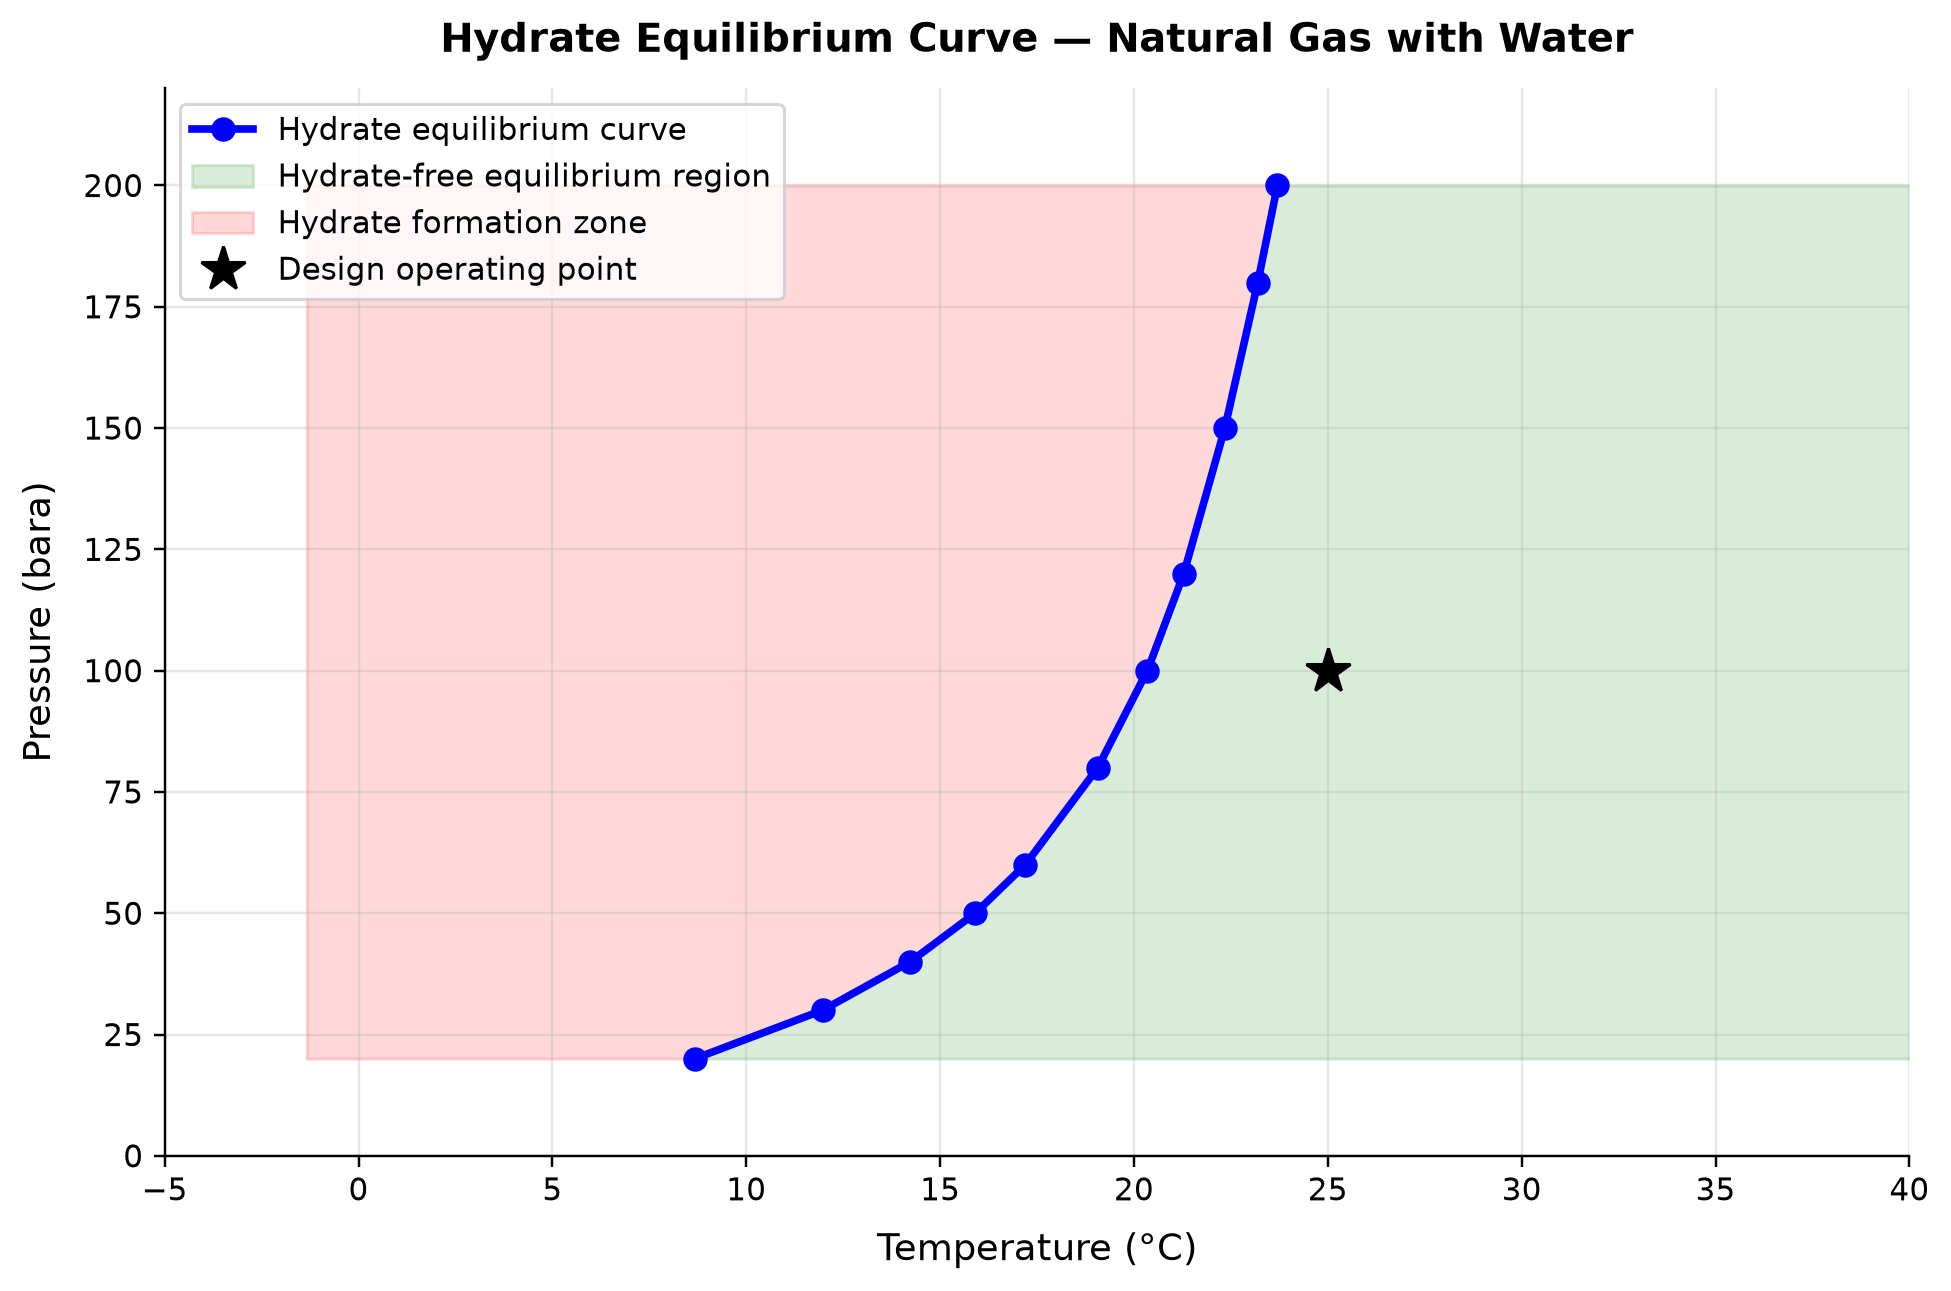

In [4]:
# Figure 1: Hydrate equilibrium curve with operating region
fig, ax = plt.subplots(figsize=(9, 6))

ax.plot(hydrate_temps_C, pressures_bara, 'b-o', linewidth=2.5, markersize=7,
        label='Hydrate equilibrium curve', zorder=5)

# Shade the hydrate-free and hydrate zones
valid_T = [t for t in hydrate_temps_C if not np.isnan(t)]
valid_P = [p for t, p in zip(hydrate_temps_C, pressures_bara) if not np.isnan(t)]
if valid_T:
    ax.fill_betweenx(valid_P, valid_T, max(valid_T) + 30,
                     alpha=0.15, color='green', label='Hydrate-free equilibrium region')
    ax.fill_betweenx(valid_P, min(valid_T) - 10, valid_T,
                     alpha=0.15, color='red', label='Hydrate formation zone')

# Example operating point
ax.plot(25, 100, 'k*', markersize=15, label='Design operating point', zorder=6)

ax.set_xlabel('Temperature (°C)', fontsize=12)
ax.set_ylabel('Pressure (bara)', fontsize=12)
ax.set_title('Hydrate Equilibrium Curve — Natural Gas with Water', fontsize=13)
ax.legend(fontsize=10, loc='upper left')
ax.grid(True, alpha=0.3)
ax.set_xlim(-5, 40)
ax.set_ylim(0, 220)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig01_hydrate_equilibrium.png", dpi=220, bbox_inches="tight")
plt.show()


**Executed-figure discussion.** The calculated hydrate equilibrium temperature rises from 8.67 °C at 20 bara to 23.70 °C at 200 bara for the stated gas and water recipe.

Higher pressure stabilizes gas hydrates at higher temperature for the specified gas and aqueous phase. The equilibrium curve defines thermodynamic susceptibility; it does not predict formation time, deposition rate or plug location. Use a validated fluid and water model, enable hydrate checking, and combine the boundary with route temperatures and an explicit operating margin.


**Discussion:** The hydrate equilibrium curve divides the T-P space into a
safe region (right/warm) and a hydrate formation zone (left/cold). At higher
pressures, hydrates form at higher temperatures, meaning that high-pressure
subsea pipelines are particularly vulnerable to hydrate formation during
shutdowns when the fluid cools toward seabed temperature (~4 °C).

## 9.2 Figure 2: Effect of MEG Concentration on Hydrate Temperature

Mono-ethylene glycol (MEG) is the most common thermodynamic hydrate
inhibitor in offshore production. It depresses the hydrate formation
temperature, widening the safe operating window.

ch08_flow_assurance_figures.ipynb:cell8:66: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


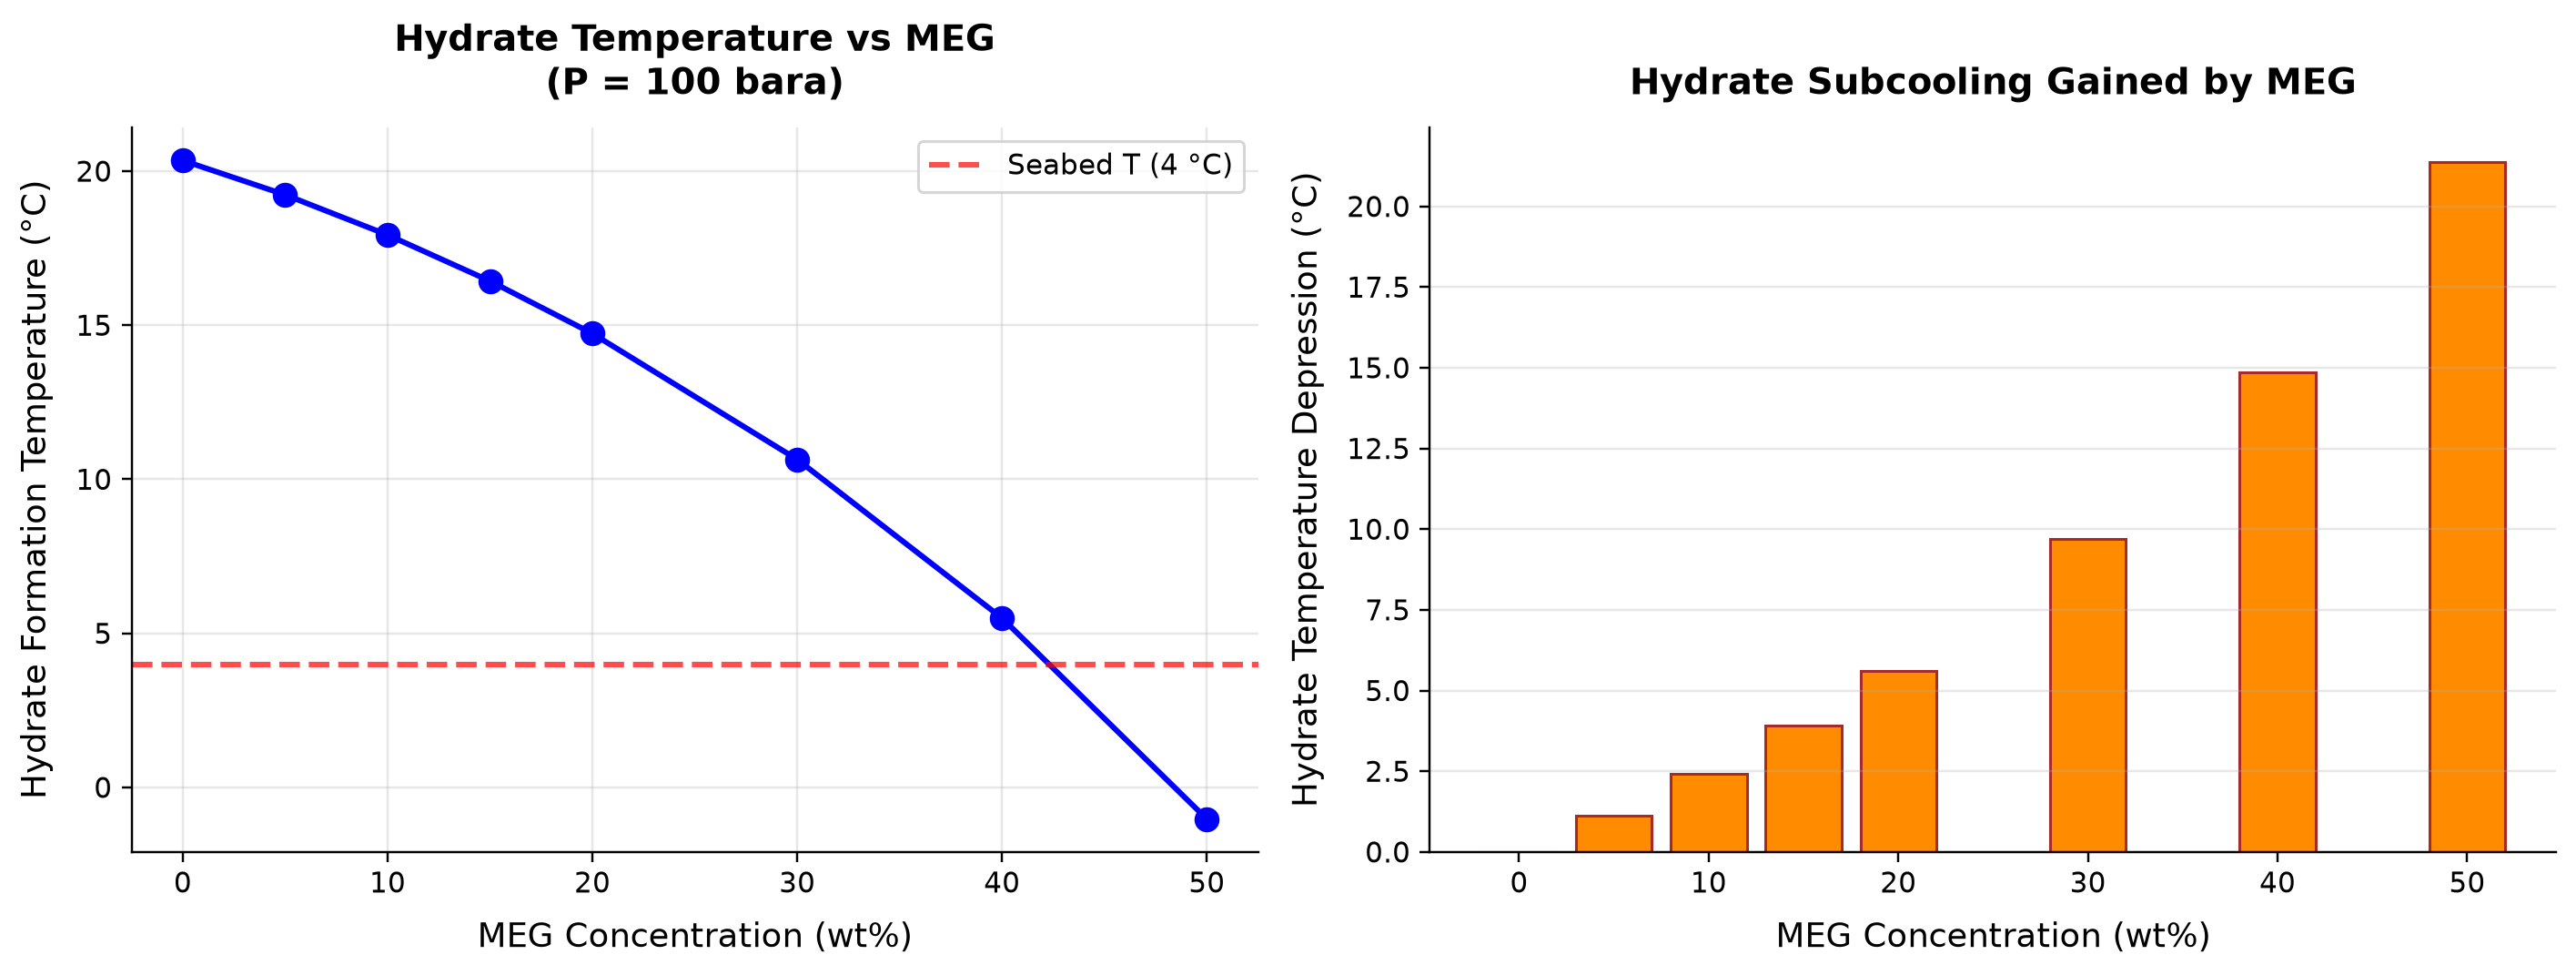

In [5]:
# MEG concentrations in weight percent of aqueous phase
meg_wt_fractions = np.array([0.0, 0.05, 0.10, 0.15, 0.20, 0.30, 0.40, 0.50])
test_pressure = 100.0  # bara
hydrate_T_with_meg = []

# Base water moles (keep gas moles constant)
water_base_moles = 0.09

for meg_wt in meg_wt_fractions:
    fluid = SystemSrkCPAstatoil(273.15 + 4.0, test_pressure)
    fluid.addComponent("methane", 0.80)
    fluid.addComponent("ethane", 0.06)
    fluid.addComponent("propane", 0.03)
    fluid.addComponent("CO2", 0.02)

    # Add water and MEG based on weight fraction
    # meg_wt = mass_MEG / (mass_MEG + mass_water)
    if meg_wt > 0.001:
        # Keep total aqueous phase similar; adjust moles
        # MW_water=18, MW_MEG=62.07
        moles_water = water_base_moles * (1.0 - meg_wt)
        moles_meg = water_base_moles * meg_wt * (18.0 / 62.07)
        fluid.addComponent("water", max(moles_water, 0.001))
        fluid.addComponent("MEG", max(moles_meg, 0.0001))
    else:
        fluid.addComponent("water", water_base_moles)

    fluid.setMixingRule(10)
    fluid.setMultiPhaseCheck(True)
    fluid.setHydrateCheck(True)

    ops = ThermodynamicOperations(fluid)
    try:
        ops.hydrateFormationTemperature()
        T_hyd = float(fluid.getTemperature("C"))
        hydrate_T_with_meg.append(T_hyd)
    except Exception:
        raise RuntimeError(f'MEG hydrate equilibrium failed at {meg_wt*100:.0f} wt%')

# Calculate depression from base case
assert np.all(np.isfinite(hydrate_T_with_meg))
base_T = hydrate_T_with_meg[0]
depression = [base_T - T if not np.isnan(T) else float('nan') for T in hydrate_T_with_meg]

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Left: Hydrate temperature vs MEG concentration
ax1.plot(meg_wt_fractions * 100, hydrate_T_with_meg, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('MEG Concentration (wt%)', fontsize=12)
ax1.set_ylabel('Hydrate Formation Temperature (°C)', fontsize=12)
ax1.set_title(f'Hydrate Temperature vs MEG\n(P = {test_pressure:.0f} bara)', fontsize=13)
ax1.grid(True, alpha=0.3)
ax1.axhline(y=4.0, color='r', linestyle='--', alpha=0.7, label='Seabed T (4 °C)')
ax1.legend(fontsize=10)

# Right: Temperature depression vs MEG
ax2.bar(meg_wt_fractions * 100, depression, color='darkorange', edgecolor='brown', width=4)
ax2.set_xlabel('MEG Concentration (wt%)', fontsize=12)
ax2.set_ylabel('Hydrate Temperature Depression (°C)', fontsize=12)
ax2.set_title('Hydrate Subcooling Gained by MEG', fontsize=13)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig02_meg_inhibition.png", dpi=220, bbox_inches="tight")
plt.show()


**Executed-figure discussion.** At 100 bara, increasing the specified aqueous MEG concentration from 0 to 50 wt% lowers hydrate equilibrium temperature from 20.35 to -1.03 °C, a depression of 21.37 °C.

MEG lowers water activity and depresses hydrate equilibrium temperature; the relevant concentration is in the aqueous phase. An injection percentage on total wellstream flow is not interchangeable with the required aqueous MEG concentration. Close the water–MEG mass balance through condensation, produced-water influx and regeneration before setting an inhibitor rate.


**Discussion:** MEG injection is effective at depressing the hydrate formation
temperature. Typical offshore systems use 20-40 wt% MEG, which provides 5-15 °C
of subcooling protection. Higher concentrations provide more protection but
increase OPEX (MEG cost, regeneration energy) and can increase viscosity.
The horizontal dashed line shows seabed temperature — MEG dosage must be
sufficient to push the hydrate curve below this line during shutdown.

## 9.3 Figure 3: Water Dew Point vs Pressure

The water dew point defines the temperature at which free water condenses from
the gas phase. Below the dew point, liquid water forms and creates risks of
corrosion, hydrates, and pipeline erosion.

Water dew point for 50 ppmv water:
  20 bara: -24.940 C
  30 bara: -20.936 C
  50 bara: -16.279 C
  70 bara: -13.762 C
  100 bara: -12.082 C
  130 bara: -11.681 C
  150 bara: -11.656 C
  180 bara: -11.690 C
  200 bara: -11.711 C


ch08_flow_assurance_figures.ipynb:cell11:39: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


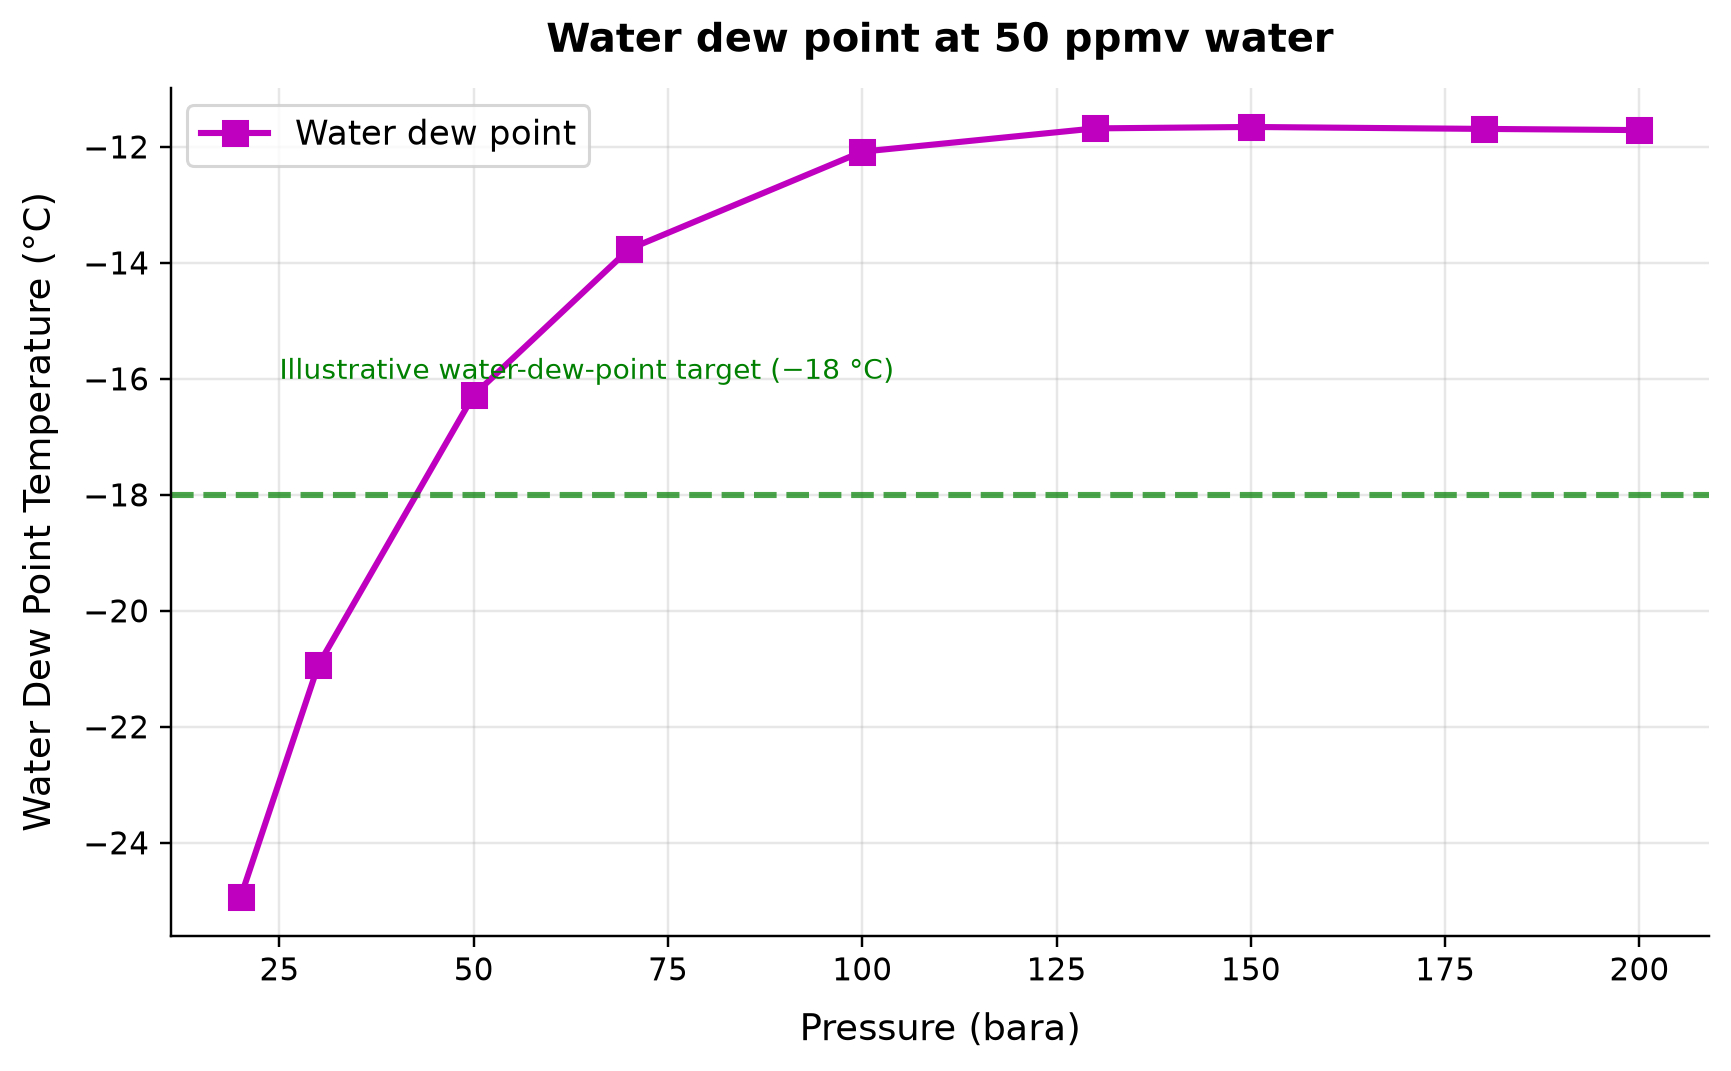

In [6]:
wdp_pressures = np.array([20, 30, 50, 70, 100, 130, 150, 180, 200])
water_dew_temps = []

for P in wdp_pressures:
    fluid = SystemSrkCPAstatoil(273.15 + 30.0, float(P))
    fluid.addComponent("methane", 0.88995)
    fluid.addComponent("ethane", 0.06)
    fluid.addComponent("propane", 0.03)
    fluid.addComponent("CO2", 0.02)
    fluid.addComponent("water", 50.0e-6)  # 50 ppmv water in total gas
    fluid.setMixingRule(10)
    fluid.setMultiPhaseCheck(True)

    ops = ThermodynamicOperations(fluid)
    ops.waterDewPointTemperatureMultiphaseFlash()
    wdp_T = float(fluid.getTemperature("C"))
    assert -100.0 < wdp_T < 80.0, f"Invalid water dew point at {P} bara: {wdp_T} C"
    water_dew_temps.append(wdp_T)
print("Water dew point for 50 ppmv water:")
for pressure, temperature in zip(wdp_pressures, water_dew_temps):
    print(f"  {pressure:.0f} bara: {temperature:.3f} C")

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(wdp_pressures, water_dew_temps, 'ms-', linewidth=2, markersize=8,
        label='Water dew point')
ax.set_xlabel('Pressure (bara)', fontsize=12)
ax.set_ylabel('Water Dew Point Temperature (°C)', fontsize=12)
ax.set_title('Water dew point at 50 ppmv water', fontsize=13)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)

# Add annotation for gas export specification
ax.axhline(y=-18, color='green', linestyle='--', alpha=0.7)
ax.text(25, -16, 'Illustrative water-dew-point target (−18 °C)', fontsize=9, color='green')

plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig03_water_dewpoint.png", dpi=220, bbox_inches="tight")
plt.show()


**Executed-figure discussion.** Water dew point: water dew point temperature spans -24.94–-11.66 °C across the plotted cases.

The water dew point is the saturation temperature corresponding to the specified gas water content at each pressure. A fixed ppmv water content has a pressure-dependent dew point, so dehydration compliance must use the contractual pressure basis. Reject solver sentinel temperatures and verify the ppmv, mg/Sm3 and standard-volume reference conversions when comparing with measurements.


**Discussion:** The water dew point generally increases with pressure for
hydrocarbon-water systems, meaning higher-pressure gas can hold less water
in the vapor phase. Gas dehydration (typically with TEG) is required to meet
export specifications (commonly −18 °C water dew point at delivery pressure).
Without dehydration, the raw gas water dew point is typically 15-30 °C.

## 9.4 Figure 4: Pipeline Operating Envelope with Hydrate Boundary

We overlay a typical pipeline temperature-pressure path with the hydrate
equilibrium curve to visualize the operating margin and identify where
the system is most vulnerable to hydrate formation.

ch08_flow_assurance_figures.ipynb:cell14:46: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


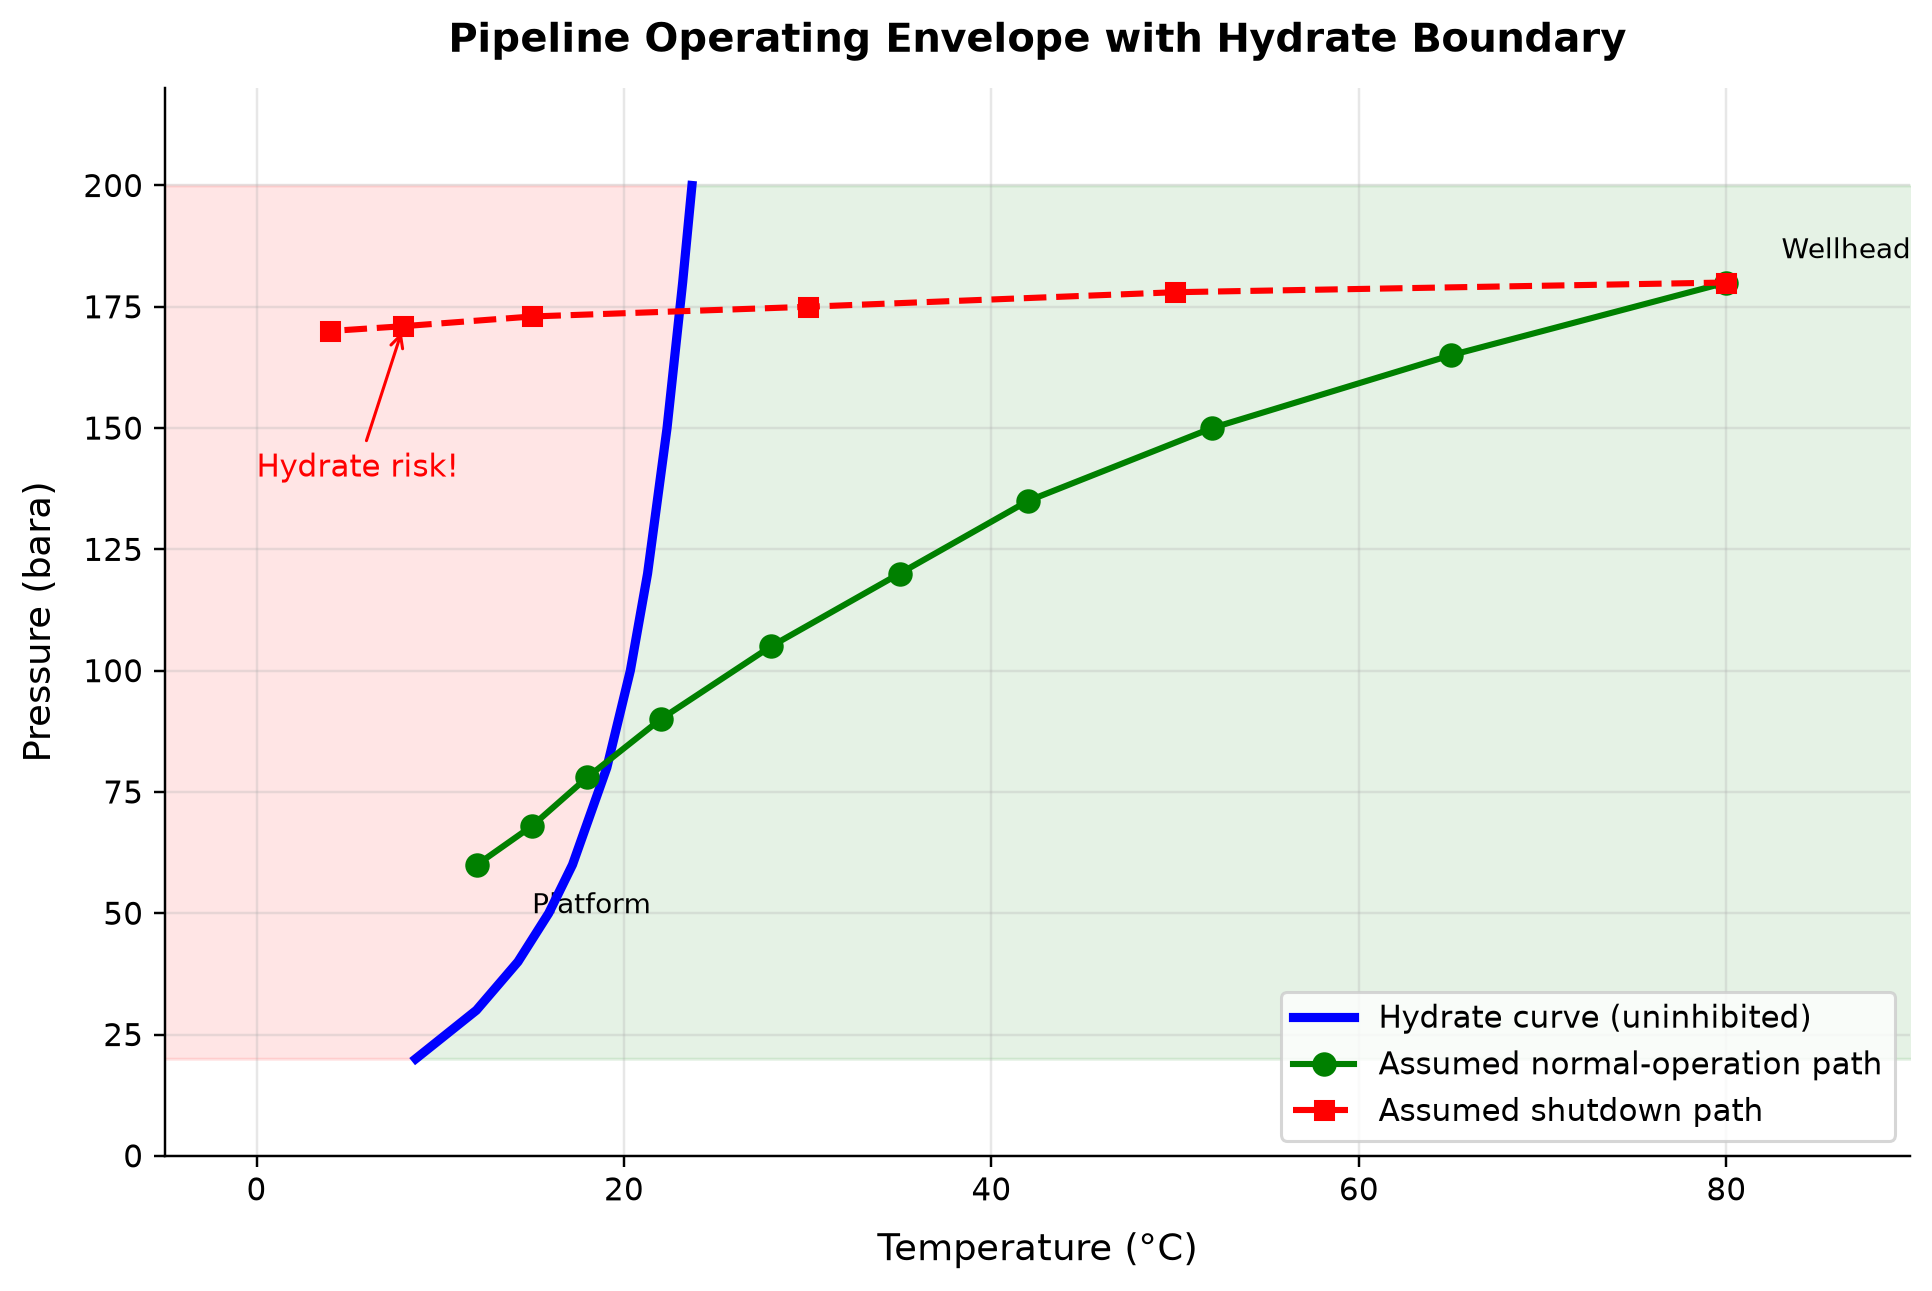

In [7]:
# Assumed illustrative pipeline T-P path (not a transient simulation) (wellhead to platform)
# Temperature cools along pipeline, pressure drops
pipeline_T = np.array([80, 65, 52, 42, 35, 28, 22, 18, 15, 12])  # °C
pipeline_P = np.array([180, 165, 150, 135, 120, 105, 90, 78, 68, 60])  # bara

# Shutdown scenario: pressure stays, temperature drops to seabed
shutdown_T = np.array([80, 50, 30, 15, 8, 4])  # °C
shutdown_P = np.array([180, 178, 175, 173, 171, 170])  # bara (nearly constant)

fig, ax = plt.subplots(figsize=(9, 6))

# Hydrate curve (from earlier calculation)
valid_mask = [not np.isnan(t) for t in hydrate_temps_C]
hyd_T_valid = [t for t, m in zip(hydrate_temps_C, valid_mask) if m]
hyd_P_valid = [p for p, m in zip(pressures_bara, valid_mask) if m]
ax.plot(hyd_T_valid, hyd_P_valid, 'b-', linewidth=3, label='Hydrate curve (uninhibited)',
        zorder=4)

# Safe region shading
ax.fill_betweenx(hyd_P_valid, hyd_T_valid, 100, alpha=0.1, color='green')
ax.fill_betweenx(hyd_P_valid, -10, hyd_T_valid, alpha=0.1, color='red')

# Pipeline operating path
ax.plot(pipeline_T, pipeline_P, 'go-', linewidth=2, markersize=7,
        label='Assumed normal-operation path', zorder=5)
ax.annotate('Wellhead', xy=(pipeline_T[0], pipeline_P[0]),
            xytext=(pipeline_T[0]+3, pipeline_P[0]+5), fontsize=9)
ax.annotate('Platform', xy=(pipeline_T[-1], pipeline_P[-1]),
            xytext=(pipeline_T[-1]+3, pipeline_P[-1]-10), fontsize=9)

# Shutdown path
ax.plot(shutdown_T, shutdown_P, 'r--s', linewidth=2, markersize=6,
        label='Assumed shutdown path', zorder=5)
ax.annotate('Hydrate risk!', xy=(8, 171), xytext=(0, 140),
            arrowprops=dict(arrowstyle='->', color='red'), fontsize=10, color='red')

ax.set_xlabel('Temperature (°C)', fontsize=12)
ax.set_ylabel('Pressure (bara)', fontsize=12)
ax.set_title('Pipeline Operating Envelope with Hydrate Boundary', fontsize=13)
ax.legend(fontsize=10, loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_xlim(-5, 90)
ax.set_ylim(0, 220)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig04_hydrate_operating_envelope.png", dpi=220, bbox_inches="tight")
plt.show()


**Executed-figure discussion.** Hydrate curve (uninhibited): pressure spans 20–200 bara across the plotted cases. Assumed normal-operation path: pressure spans 60–180 bara across the plotted cases.

The distance between the operating path and hydrate boundary reflects the combined effects of cooling, pressure loss and inhibition. A nominal warm steady-state case can conceal vulnerability during turndown, shutdown or restart. Evaluate the full operating envelope, including uncertainty and transient cooldown, and document the minimum temperature margin along the route.


**Discussion:** During normal operation, the pipeline path stays well to the
right of the hydrate curve (safe). However, during a shutdown the fluid cools
toward seabed temperature (4 °C) while pressure remains high — crossing the
hydrate boundary and entering the formation zone. This is why:
- MEG injection must be continuous during production
- Depressurization procedures are critical during planned shutdowns
- Insulation and active heating extend the no-touch time before hydrate risk

## Summary

Key takeaways from this chapter:

1. **Hydrate equilibrium** depends on gas composition and pressure — higher
   pressure means higher hydrate formation temperature.
2. **MEG injection** of 20-40 wt% is the standard inhibition strategy for
   offshore gas production, providing 5-15 °C of subcooling margin.
3. **Water dew point** increases with pressure, requiring dehydration for export.
4. **Shutdown scenarios** are the most critical flow assurance risk — the pipeline
   T-P path crosses into the hydrate zone as temperature drops.

## Numerical output and figure provenance
The following table is extracted from the plotted numerical data. Each saved figure has an adjacent CSV and JSON record; missing points remain visible and are not replaced by interpolated results. Extrema summarize the sampled operating envelope, and are not independent validation of the model.


In [8]:
figure_results = export_figure_summary(NOTEBOOK_PATH)
print(figure_results.to_string(index=False, float_format=lambda value: f'{value:.6g}'))


                              Figure  Panel                        Series                       Output / unit  Minimum  Maximum  Finite points  Missing points
       fig01_hydrate_equilibrium.png      1     Hydrate equilibrium curve                     Pressure (bara)       20      200             11               0
       fig01_hydrate_equilibrium.png      1        Design operating point                     Pressure (bara)      100      100              1               0
            fig02_meg_inhibition.png      1                       Curve 1  Hydrate Formation Temperature (°C) -1.02648  20.3466              8               0
            fig02_meg_inhibition.png      1               Seabed T (4 °C)  Hydrate Formation Temperature (°C)        4        4              2               0
            fig02_meg_inhibition.png      2                        Bars 1 Hydrate Temperature Depression (°C)        0   21.373              8               0
            fig03_water_dewpoint.png      1   

## Physical verification and its limits
The assertions above test the calculated states and steady-state conservation laws. Rejected operating candidates remain excluded; they do not become synthetic outputs. The chapter-specific checks below state the applicable limits. Independent reference-fluid and analytic benchmarks are recorded separately in `verification/scientific_revision/benchmark_results.json`. Passing these checks does not establish field calibration or an installed equipment rating.


In [9]:
from chapter_specific_checks import validate_chapter
assert validate_chapter(_physics, globals())
assert _physics.finish()


Physics verification: 33 distinct checks, 33 evaluations; 0 rejected nonphysical candidates.


## Physical verification and scope

Hydrate/inhibitor/dew-point domains and monotonic sensitivities. No measured hydrate or inhibited-water dataset; composition and inhibitor basis must match the application.

The final code cell checks the computed cases against explicit physical, analytical or constraint criteria. A passed conservation check establishes internal consistency; it does not establish field accuracy. Independent reference values, actual model results, units, acceptance tolerances and source provenance are retained in the [benchmark notebook](../../../verification/scientific_revision/36_benchmark_validation.ipynb), [benchmark results](../../../verification/scientific_revision/benchmark_results.json) and [chapter validation ledger](../../../verification/scientific_revision/notebook_physics_review.md).
